# U23AI035 - LAB 2 Assignment - DL

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam
import matplotlib.pyplot as plt

In [23]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [24]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [25]:
x_train_cnn = x_train[..., None]
x_test_cnn = x_test[..., None]

In [26]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

### CNN Model

In [27]:
cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

history_cnn = cnn_model.fit(
    x_train_cnn, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

cnn_acc = cnn_model.evaluate(x_test_cnn, y_test, verbose=0)[1]
print("CNN Test Accuracy:", cnn_acc)

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 conv2d_21 (Conv2D)          (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 12, 12, 64)       0         
 g2D)                                                            
                                                                 
 dropout_10 (Dropout)        (None, 12, 12, 64)        0         
                                                                 
 flatten_12 (Flatten)        (None, 9216)              0         
                                                                 
 dense_26 (Dense)            (None, 128)               1179776   
                                                     

### MLP Model

In [28]:
def create_mlp(fc_layers, optimizer):
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=(28,28)))

    for units in fc_layers:
        model.add(layers.Dense(units))
        model.add(layers.BatchNormalization())
        model.add(layers.ReLU())

    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [29]:
mlp1 = create_mlp([512, 256, 128], optimizer='sgd')

history_mlp1 = mlp1.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1
)

mlp1_acc = mlp1.evaluate(x_test, y_test, verbose=0)[1]
print("MLP-1 Test Accuracy:", mlp1_acc)

Epoch 1/20
422/422 [==============================] - 7s 16ms/step - loss: 0.6033 - accuracy: 0.8402 - val_loss: 0.2860 - val_accuracy: 0.9385
Epoch 2/20
422/422 [==============================] - 2s 5ms/step - loss: 0.2661 - accuracy: 0.9307 - val_loss: 0.1816 - val_accuracy: 0.9560
Epoch 3/20
422/422 [==============================] - 2s 5ms/step - loss: 0.1988 - accuracy: 0.9482 - val_loss: 0.1460 - val_accuracy: 0.9625
Epoch 4/20
422/422 [==============================] - 2s 4ms/step - loss: 0.1617 - accuracy: 0.9569 - val_loss: 0.1268 - val_accuracy: 0.9665
Epoch 5/20
422/422 [==============================] - 2s 5ms/step - loss: 0.1372 - accuracy: 0.9639 - val_loss: 0.1145 - val_accuracy: 0.9702
Epoch 6/20
422/422 [==============================] - 2s 5ms/step - loss: 0.1183 - accuracy: 0.9693 - val_loss: 0.1049 - val_accuracy: 0.9713
Epoch 7/20
422/422 [==============================] - 2s 6ms/step - loss: 0.1034 - accuracy: 0.9725 - val_loss: 0.0985 - val_accuracy: 0.9725
Epoch

In [30]:
mlp2 = create_mlp([256], optimizer='adam')

history_mlp2 = mlp2.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

mlp2_acc = mlp2.evaluate(x_test, y_test, verbose=0)[1]
print("MLP-2 Test Accuracy:", mlp2_acc)

Epoch 1/15
422/422 [==============================] - 1s 3ms/step - loss: 0.2590 - accuracy: 0.9255 - val_loss: 0.1257 - val_accuracy: 0.9670
Epoch 2/15
422/422 [==============================] - 1s 2ms/step - loss: 0.1131 - accuracy: 0.9683 - val_loss: 0.0933 - val_accuracy: 0.9740
Epoch 3/15
422/422 [==============================] - 1s 2ms/step - loss: 0.0759 - accuracy: 0.9797 - val_loss: 0.0916 - val_accuracy: 0.9762
Epoch 4/15
422/422 [==============================] - 1s 2ms/step - loss: 0.0553 - accuracy: 0.9857 - val_loss: 0.0782 - val_accuracy: 0.9772
Epoch 5/15
422/422 [==============================] - 1s 2ms/step - loss: 0.0415 - accuracy: 0.9889 - val_loss: 0.0792 - val_accuracy: 0.9772
Epoch 6/15
422/422 [==============================] - 1s 2ms/step - loss: 0.0309 - accuracy: 0.9923 - val_loss: 0.0749 - val_accuracy: 0.9805
Epoch 7/15
422/422 [==============================] - 1s 2ms/step - loss: 0.0241 - accuracy: 0.9940 - val_loss: 0.0739 - val_accuracy: 0.9798
Epoch 

| model | FC Layer | Optimizer | Epochs | Accuracy |
|-------|----------|-----------|--------|----------|
| CNN-1 | 128 | Adam | 10 | 98.71% |
| MLP-1 | 512-256-128 | SGD | 20 | 97.71% |
| MLP-2 | 256 | Adam | 15 | 97.63% |

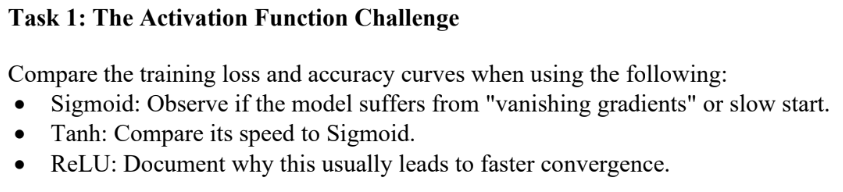

In [31]:
def build_cnn(activation):
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3,3), activation=activation),
        layers.Conv2D(64, (3,3), activation=activation),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation=activation),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [32]:
activations = ['sigmoid', 'tanh', 'relu']
cnn_histories = {}
accs = {}

for act in activations:
    print(f"\nTraining CNN with {act.upper()} activation")
    
    model = build_cnn(act)
    
    history = model.fit(
        x_train_cnn, y_train,
        epochs=20,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )
    cnn_acc = model.evaluate(x_test_cnn, y_test, verbose=0)[1]
    accs[act] = cnn_acc
    cnn_histories[act] = history


Training CNN with SIGMOID activation
Epoch 1/20
422/422 [==============================] - 3s 6ms/step - loss: 2.3430 - accuracy: 0.1090 - val_loss: 2.3042 - val_accuracy: 0.1050
Epoch 2/20
422/422 [==============================] - 2s 5ms/step - loss: 2.3041 - accuracy: 0.1078 - val_loss: 2.3055 - val_accuracy: 0.1050
Epoch 3/20
422/422 [==============================] - 2s 5ms/step - loss: 2.3051 - accuracy: 0.1063 - val_loss: 2.3036 - val_accuracy: 0.1045
Epoch 4/20
422/422 [==============================] - 2s 5ms/step - loss: 2.3036 - accuracy: 0.1070 - val_loss: 2.3041 - val_accuracy: 0.0992
Epoch 5/20
422/422 [==============================] - 2s 5ms/step - loss: 2.3046 - accuracy: 0.1065 - val_loss: 2.3044 - val_accuracy: 0.0992
Epoch 6/20
422/422 [==============================] - 2s 5ms/step - loss: 2.3042 - accuracy: 0.1072 - val_loss: 2.3071 - val_accuracy: 0.1050
Epoch 7/20
422/422 [==============================] - 2s 5ms/step - loss: 2.3044 - accuracy: 0.1066 - val_loss

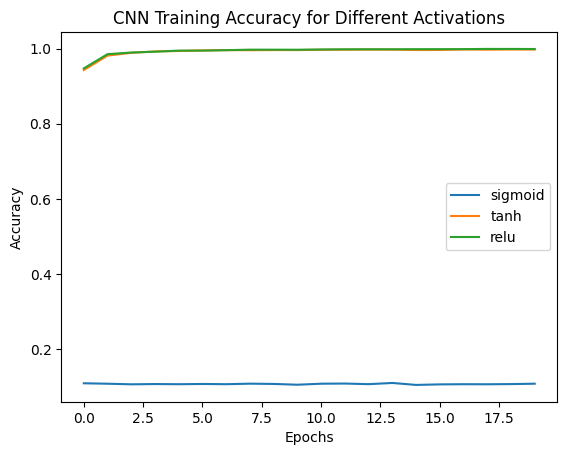

In [33]:
plt.figure()
for act in activations:
    plt.plot(cnn_histories[act].history['accuracy'], label=act)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Training Accuracy for Different Activations')
plt.legend()
plt.show()

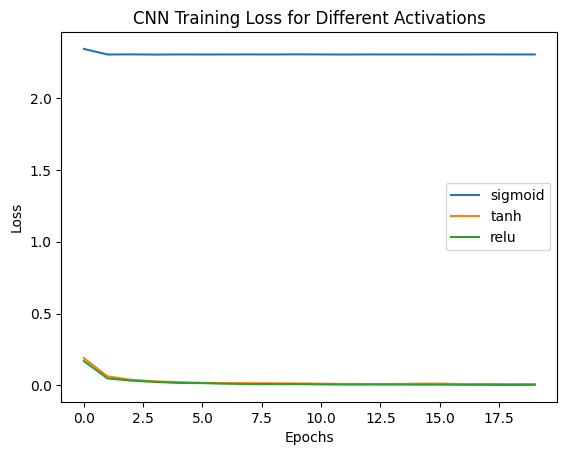

In [34]:
plt.figure()
for act in activations:
    plt.plot(cnn_histories[act].history['loss'], label=act)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Training Loss for Different Activations')
plt.legend()
plt.show()

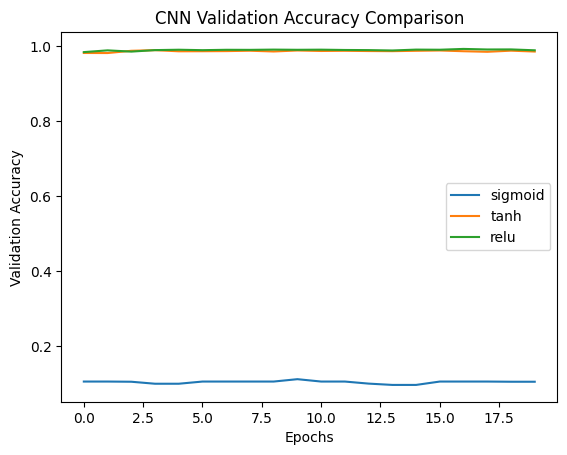

In [35]:
plt.figure()
for act in activations:
    plt.plot(cnn_histories[act].history['val_accuracy'], label=act)

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('CNN Validation Accuracy Comparison')
plt.legend()
plt.show()

In [36]:
accs

{'sigmoid': 0.10100000351667404,
 'tanh': 0.9837999939918518,
 'relu': 0.9891999959945679}

In [37]:
def build_cnn(optimizer):
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

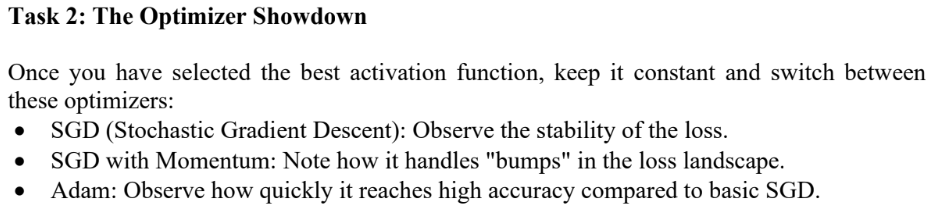

In [38]:
optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "SGD+Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "Adam": Adam(learning_rate=0.001)
}
cnn_histories = {}
accs = {}

In [39]:
for name, opt in optimizers.items():
    print(f"\nTraining with optimizer: {name}")
    
    model = build_cnn(opt)
    
    history = model.fit(
        x_train_cnn, y_train,
        epochs=10,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )
    accs[name] = model.evaluate(x_test_cnn, y_test, verbose=0)[1]
    cnn_histories[name] = history


Training with optimizer: SGD
Epoch 1/10
422/422 [==============================] - 3s 6ms/step - loss: 0.7962 - accuracy: 0.7731 - val_loss: 0.2627 - val_accuracy: 0.9223
Epoch 2/10
422/422 [==============================] - 2s 5ms/step - loss: 0.3285 - accuracy: 0.9002 - val_loss: 0.1985 - val_accuracy: 0.9455
Epoch 3/10
422/422 [==============================] - 2s 5ms/step - loss: 0.2615 - accuracy: 0.9206 - val_loss: 0.1615 - val_accuracy: 0.9540
Epoch 4/10
422/422 [==============================] - 2s 5ms/step - loss: 0.2161 - accuracy: 0.9339 - val_loss: 0.1450 - val_accuracy: 0.9600
Epoch 5/10
422/422 [==============================] - 2s 5ms/step - loss: 0.1873 - accuracy: 0.9424 - val_loss: 0.1319 - val_accuracy: 0.9660
Epoch 6/10
422/422 [==============================] - 2s 5ms/step - loss: 0.1641 - accuracy: 0.9508 - val_loss: 0.1080 - val_accuracy: 0.9697
Epoch 7/10
422/422 [==============================] - 2s 5ms/step - loss: 0.1467 - accuracy: 0.9551 - val_loss: 0.1011

In [40]:
accs

{'SGD': 0.9747999906539917,
 'SGD+Momentum': 0.989300012588501,
 'Adam': 0.9900000095367432}

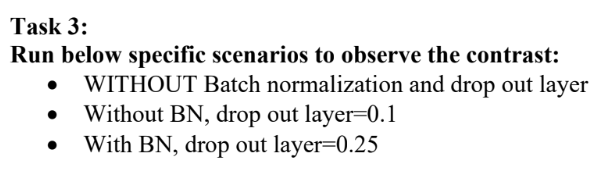

### Without BN and Drop Out layer

In [45]:
model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

history = model.fit(
        x_train_cnn, y_train,
        epochs=15,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

acc = model.evaluate(x_test_cnn, y_test, verbose=0)[1]
cnn_history = history

Epoch 1/15
422/422 [==============================] - 3s 5ms/step - loss: 0.1701 - accuracy: 0.9494 - val_loss: 0.0567 - val_accuracy: 0.9838
Epoch 2/15
422/422 [==============================] - 2s 5ms/step - loss: 0.0472 - accuracy: 0.9857 - val_loss: 0.0422 - val_accuracy: 0.9873
Epoch 3/15
422/422 [==============================] - 2s 5ms/step - loss: 0.0300 - accuracy: 0.9905 - val_loss: 0.0455 - val_accuracy: 0.9883
Epoch 4/15
422/422 [==============================] - 2s 5ms/step - loss: 0.0199 - accuracy: 0.9939 - val_loss: 0.0393 - val_accuracy: 0.9902
Epoch 5/15
422/422 [==============================] - 2s 5ms/step - loss: 0.0145 - accuracy: 0.9955 - val_loss: 0.0413 - val_accuracy: 0.9890
Epoch 6/15
422/422 [==============================] - 2s 5ms/step - loss: 0.0106 - accuracy: 0.9967 - val_loss: 0.0370 - val_accuracy: 0.9902
Epoch 7/15
422/422 [==============================] - 2s 5ms/step - loss: 0.0084 - accuracy: 0.9971 - val_loss: 0.0418 - val_accuracy: 0.9893
Epoch 

In [46]:
acc

0.9890999794006348

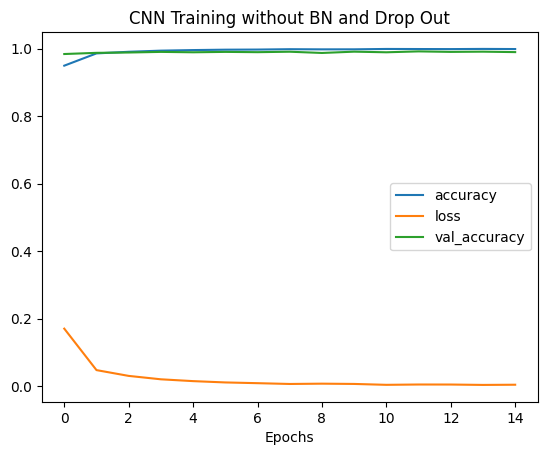

In [48]:
plt.figure()
plt.plot(cnn_history.history['accuracy'], label='accuracy')
plt.plot(cnn_history.history['loss'], label='loss')
plt.plot(cnn_history.history['val_accuracy'], label='val_accuracy')

plt.xlabel('Epochs')
plt.title('CNN Training without BN and Drop Out')
plt.legend()
plt.show()

### Without BN and Drop Out = 0.1

In [53]:
model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.1),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

history = model.fit(
        x_train_cnn, y_train,
        epochs=20,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

acc = model.evaluate(x_test_cnn, y_test, verbose=0)[1]
cnn_history = history

Epoch 1/20
422/422 [==============================] - 3s 6ms/step - loss: 0.1722 - accuracy: 0.9475 - val_loss: 0.0573 - val_accuracy: 0.9833
Epoch 2/20
422/422 [==============================] - 2s 5ms/step - loss: 0.0480 - accuracy: 0.9851 - val_loss: 0.0454 - val_accuracy: 0.9877
Epoch 3/20
422/422 [==============================] - 2s 5ms/step - loss: 0.0306 - accuracy: 0.9904 - val_loss: 0.0456 - val_accuracy: 0.9887
Epoch 4/20
422/422 [==============================] - 2s 5ms/step - loss: 0.0199 - accuracy: 0.9936 - val_loss: 0.0363 - val_accuracy: 0.9910
Epoch 5/20
422/422 [==============================] - 2s 5ms/step - loss: 0.0159 - accuracy: 0.9947 - val_loss: 0.0446 - val_accuracy: 0.9900
Epoch 6/20
422/422 [==============================] - 2s 5ms/step - loss: 0.0111 - accuracy: 0.9964 - val_loss: 0.0457 - val_accuracy: 0.9905
Epoch 7/20
422/422 [==============================] - 2s 5ms/step - loss: 0.0098 - accuracy: 0.9972 - val_loss: 0.0369 - val_accuracy: 0.9927
Epoch 

In [54]:
acc

0.9909999966621399

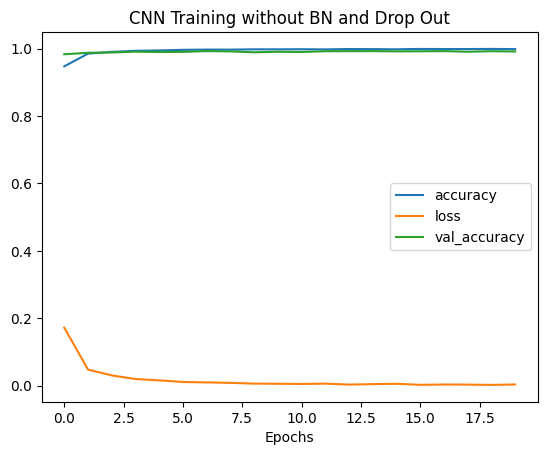

In [55]:
plt.figure()
plt.plot(cnn_history.history['accuracy'], label='accuracy')
plt.plot(cnn_history.history['loss'], label='loss')
plt.plot(cnn_history.history['val_accuracy'], label='val_accuracy')

plt.xlabel('Epochs')
plt.title('CNN Training without BN and Drop Out')
plt.legend()
plt.show()

### With BN and Drop Out = 0.25

In [62]:
model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

history = model.fit(
        x_train_cnn, y_train,
        epochs=20,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

acc = model.evaluate(x_test_cnn, y_test, verbose=0)[1]
cnn_history = history

Epoch 1/20
422/422 [==============================] - 3s 7ms/step - loss: 0.1670 - accuracy: 0.9553 - val_loss: 1.0051 - val_accuracy: 0.7300
Epoch 2/20
422/422 [==============================] - 3s 6ms/step - loss: 0.0507 - accuracy: 0.9846 - val_loss: 0.0545 - val_accuracy: 0.9863
Epoch 3/20
422/422 [==============================] - 3s 6ms/step - loss: 0.0318 - accuracy: 0.9897 - val_loss: 0.0388 - val_accuracy: 0.9897
Epoch 4/20
422/422 [==============================] - 3s 6ms/step - loss: 0.0233 - accuracy: 0.9925 - val_loss: 0.0551 - val_accuracy: 0.9882
Epoch 5/20
422/422 [==============================] - 3s 6ms/step - loss: 0.0189 - accuracy: 0.9942 - val_loss: 0.0569 - val_accuracy: 0.9880
Epoch 6/20
422/422 [==============================] - 3s 6ms/step - loss: 0.0192 - accuracy: 0.9941 - val_loss: 0.0588 - val_accuracy: 0.9885
Epoch 7/20
422/422 [==============================] - 3s 6ms/step - loss: 0.0168 - accuracy: 0.9949 - val_loss: 0.0543 - val_accuracy: 0.9897
Epoch 

In [63]:
acc

0.9876999855041504

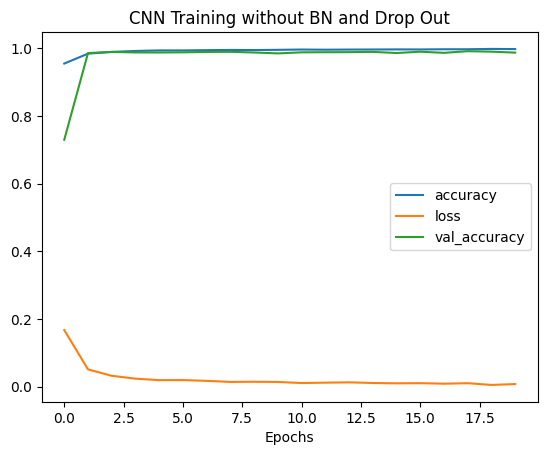

In [64]:
plt.figure()
plt.plot(cnn_history.history['accuracy'], label='accuracy')
plt.plot(cnn_history.history['loss'], label='loss')
plt.plot(cnn_history.history['val_accuracy'], label='val_accuracy')

plt.xlabel('Epochs')
plt.title('CNN Training without BN and Drop Out')
plt.legend()
plt.show()

| Expirement | Activation | Optimizer | Epochs | Final Accuracy |
|-------|----------|-----------|--------|----------|
| 1 | ReLU | Adam | 20 | 99.11% |
| 2 | ReLU | Adam | 10 | 99.19% |
| 3 (Without BN & DP=0.1) | ReLU | Adam | 20 | 99.09% |